In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
for p in RESULTS_DIR.rglob("*"):
    if p.is_file():
        print(p)

/Users/abhra/Downloads/AI-ML/Resume/BraTS/results/v2/v2_qualitative_image.png
/Users/abhra/Downloads/AI-ML/Resume/BraTS/results/v4/v4_test_126_patients.json


In [4]:
v4_result = {
    "Version": "V4",
    "Architecture": "3D U-Net",
    "Input": "4-channel 3D MRI patches",
    "Dice": 0.8079,
    "IoU": 0.7111
}

print(v4_result)

{'Version': 'V4', 'Architecture': '3D U-Net', 'Input': '4-channel 3D MRI patches', 'Dice': 0.8079, 'IoU': 0.7111}


In [14]:
comparison = pd.DataFrame([
    {
        "Version": "V2",
        "Architecture": "2D U-Net",
        "Input": "2D MRI slices",
        "Overall Pixel Dice": 0.9294,
        "Mean Slice Dice": 0.8240,
        "Tumor Slice Dice": 0.8393,
        "IoU": 0.8681,
        "Precision": 0.9380,
        "Recall": 0.9209,
        "Specificity": 0.9992,
    },
    {
        "Version": "V3",
        "Architecture": "2.5D U-Net",
        "Input": "Multi-slice 2D context",
        "Overall Pixel Dice": 0.9277,
        "Mean Slice Dice": 0.8399,
        "Tumor Slice Dice": 0.8508,
        "IoU": 0.8652,
        "Precision": 0.9177,
        "Recall": 0.9380,
        "Specificity": 0.9989,
    },
    {
        "Version": "V4",
        "Architecture": "3D U-Net",
        "Input": "4-channel 3D MRI patches",
        "Overall Pixel Dice": None,
        "Mean Slice Dice": None,
        "Tumor Slice Dice": 0.8079,
        "IoU": 0.7111,
        "Precision": None,
        "Recall": None,
        "Specificity": None,
    },
])

display(comparison)

,Version,Architecture,Input,Overall Pixel Dice,Mean Slice Dice,Tumor Slice Dice,IoU,Precision,Recall,Specificity
0,V2,2D U-Net,2D MRI slices,0.9294,0.8240,0.8393,0.8681,0.9380,0.9209,0.9992
1,V3,2.5D U-Net,Multi-slice 2D context,0.9277,0.8399,0.8508,0.8652,0.9177,0.9380,0.9989
2,V4,3D U-Net,4-channel 3D MRI patches,NaN,NaN,0.8079,0.7111,NaN,NaN,NaN


In [15]:
summary = comparison[
    [
        "Version",
        "Architecture",
        "Overall Pixel Dice",
        "Mean Slice Dice",
        "Tumor Slice Dice",
        "IoU",
        "Precision",
        "Recall",
        "Specificity",
    ]
]

display(
    summary.style.format({
        "Overall Pixel Dice": "{:.4f}",
        "Mean Slice Dice": "{:.4f}",
        "Tumor Slice Dice": "{:.4f}",
        "IoU": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Specificity": "{:.4f}",
    })
)

,Version,Architecture,Overall Pixel Dice,Mean Slice Dice,Tumor Slice Dice,IoU,Precision,Recall,Specificity
0,V2,2D U-Net,0.9294,0.8240,0.8393,0.8681,0.9380,0.9209,0.9992
1,V3,2.5D U-Net,0.9277,0.8399,0.8508,0.8652,0.9177,0.9380,0.9989
2,V4,3D U-Net,nan,nan,0.8079,0.7111,nan,nan,nan


In [16]:
architecture_progression = pd.DataFrame([
    ["V2", "2D U-Net", "Single-slice"],
    ["V3", "2.5D U-Net", "Multi-slice context"],
    ["V4", "3D U-Net", "Full volumetric context"],
], columns=["Version", "Architecture", "Spatial Context"])

display(architecture_progression)

,Version,Architecture,Spatial Context
0,V2,2D U-Net,Single-slice
1,V3,2.5D U-Net,Multi-slice context
2,V4,3D U-Net,Full volumetric context


In [17]:
v2_v3 = comparison[
    comparison["Version"].isin(["V2", "V3"])
]

metrics = [
    "Overall Pixel Dice",
    "Mean Slice Dice",
    "Tumor Slice Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
]

display(
    v2_v3[
        ["Version"] + metrics
    ].set_index("Version").T
)

Version,V2,V3
Overall Pixel Dice,0.9294,0.9277
Mean Slice Dice,0.8240,0.8399
Tumor Slice Dice,0.8393,0.8508
IoU,0.8681,0.8652
Precision,0.9380,0.9177
Recall,0.9209,0.9380
Specificity,0.9992,0.9989


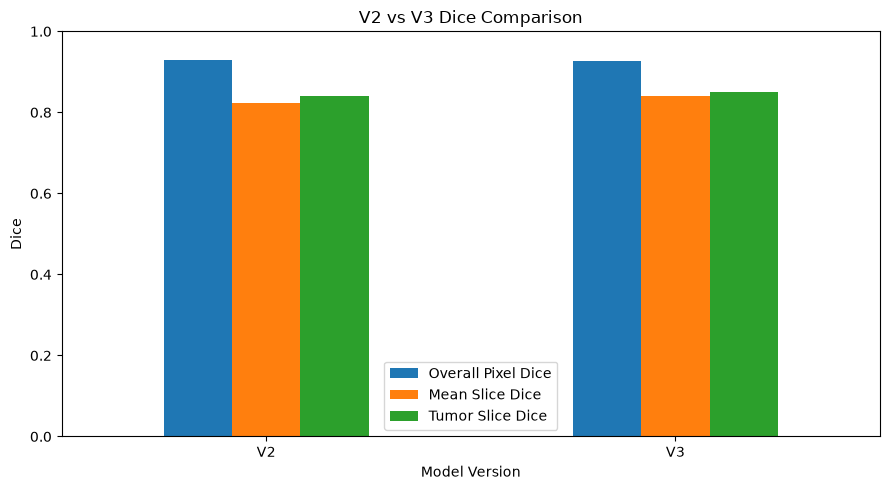

In [19]:
dice_data = pd.DataFrame({
    "Version": ["V2", "V3"],
    "Overall Pixel Dice": [0.9294, 0.9277],
    "Mean Slice Dice": [0.8240, 0.8399],
    "Tumor Slice Dice": [0.8393, 0.8508]
})

ax = dice_data.set_index("Version").plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_ylabel("Dice")
ax.set_xlabel("Model Version")
ax.set_title("V2 vs V3 Dice Comparison")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
v4_summary = pd.DataFrame({
    "Metric": [
        "Mean Dice",
        "Median Dice",
        "Std Dice",
        "Best Dice",
        "Worst Dice",
        "Mean IoU",
        "Std IoU"
    ],
    "Value": [
        v4_results["dice"].mean(),
        v4_results["dice"].median(),
        v4_results["dice"].std(),
        v4_results["dice"].max(),
        v4_results["dice"].min(),
        v4_results["iou"].mean(),
        v4_results["iou"].std()
    ]
})

display(
    v4_summary.style.format({
        "Value": "{:.4f}"
    })
)

,Metric,Value
0,Mean Dice,0.8079
1,Median Dice,0.8852
2,Std Dice,0.1909
3,Best Dice,0.9689
4,Worst Dice,0.0075
5,Mean IoU,0.7111
6,Std IoU,0.2125


In [24]:
architecture = pd.DataFrame([
    {
        "Version": "V2",
        "Architecture": "2D U-Net",
        "Spatial Context": "Single slice",
        "Evaluation": "Slice-level"
    },
    {
        "Version": "V3",
        "Architecture": "2.5D U-Net",
        "Spatial Context": "Multiple adjacent slices",
        "Evaluation": "Slice-level"
    },
    {
        "Version": "V4",
        "Architecture": "3D U-Net",
        "Spatial Context": "Full 3D patch",
        "Evaluation": "Patient-level"
    }
])

display(architecture)

,Version,Architecture,Spatial Context,Evaluation
0,V2,2D U-Net,Single slice,Slice-level
1,V3,2.5D U-Net,Multiple adjacent slices,Slice-level
2,V4,3D U-Net,Full 3D patch,Patient-level


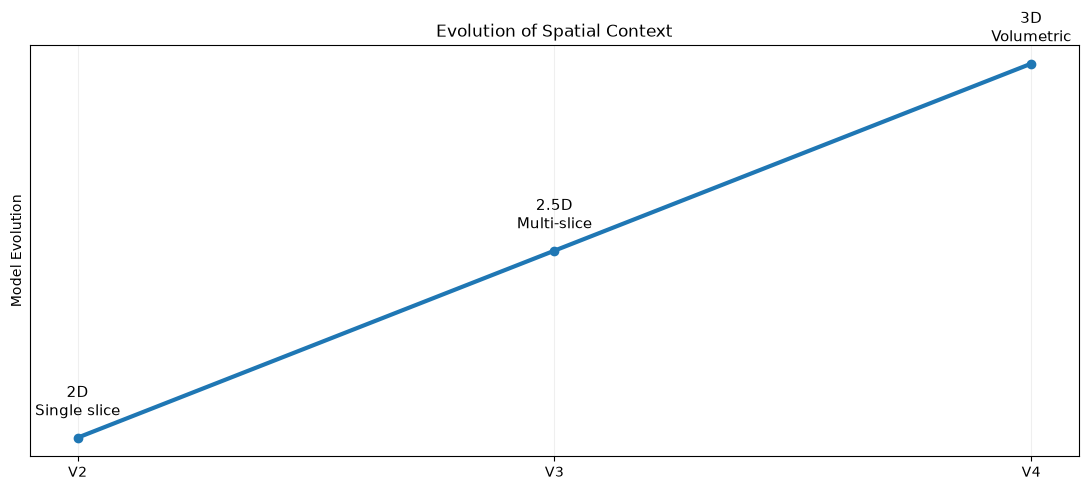

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))

versions = ["V2", "V3", "V4"]
context = [
    "2D\nSingle slice",
    "2.5D\nMulti-slice",
    "3D\nVolumetric"
]

ax.plot(
    versions,
    [1, 2, 3],
    marker="o",
    linewidth=3
)

for i, label in enumerate(context):
    ax.text(
        i,
        [1, 2, 3][i] + 0.12,
        label,
        ha="center",
        fontsize=11
    )

ax.set_title("Evolution of Spatial Context")
ax.set_ylabel("Model Evolution")
ax.set_yticks([])

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [20]:
print("""
============================================================
MODEL EVOLUTION: V2 → V3 → V4
============================================================

V2
- 2D U-Net
- Single-slice MRI context
- Tumor Slice Dice: 0.8393
- Overall Pixel Dice: 0.9294
- IoU: 0.8681

V3
- 2.5D U-Net
- Multi-slice spatial context
- Tumor Slice Dice: 0.8508
- Overall Pixel Dice: 0.9277
- IoU: 0.8652

V4
- 3D U-Net
- 4-channel volumetric MRI patches
- 126-patient patient-level evaluation
- Mean Dice: 0.8079
- Mean IoU: 0.7111

KEY OBSERVATION
----------------
V3 improved tumor-slice Dice and recall over V2, showing
that additional spatial context helped tumor detection.

V4 represents a larger architectural transition from
slice-based segmentation to full 3D volumetric segmentation.
Its evaluation uses a patient-level protocol, so its metrics
should not be directly ranked against the V2/V3 slice-level
metrics.

The V4 results also show substantial patient-level variation,
with Dice ranging from 0.0075 to 0.9689. This motivates
further error analysis and potential V5 improvements.
============================================================
""")


MODEL EVOLUTION: V2 → V3 → V4

V2
- 2D U-Net
- Single-slice MRI context
- Tumor Slice Dice: 0.8393
- Overall Pixel Dice: 0.9294
- IoU: 0.8681

V3
- 2.5D U-Net
- Multi-slice spatial context
- Tumor Slice Dice: 0.8508
- Overall Pixel Dice: 0.9277
- IoU: 0.8652

V4
- 3D U-Net
- 4-channel volumetric MRI patches
- 126-patient patient-level evaluation
- Mean Dice: 0.8079
- Mean IoU: 0.7111

KEY OBSERVATION
----------------
V3 improved tumor-slice Dice and recall over V2, showing
that additional spatial context helped tumor detection.

V4 represents a larger architectural transition from
slice-based segmentation to full 3D volumetric segmentation.
Its evaluation uses a patient-level protocol, so its metrics
should not be directly ranked against the V2/V3 slice-level
metrics.

The V4 results also show substantial patient-level variation,
with Dice ranging from 0.0075 to 0.9689. This motivates
further error analysis and potential V5 improvements.

